[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/Machine-Learning-from-scratch/blob/master/topics/11_clustering/exercises.ipynb)

# Clustering — Exercises

Test your understanding of K-Means, DBSCAN, and GMM/EM.

**Prerequisites:** [theory.md](theory.md), [first_principles.ipynb](first_principles.ipynb)

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

SEED = 42
random.seed(SEED)
rng = np.random.default_rng(SEED)

plt.rcParams["figure.dpi"] = 90

---
## Exercise 1 — Hand Calculation: Two K-Means Iterations

Given 6 points in 2D:

| Point | $x_1$ | $x_2$ |
|-------|-------|-------|
| A     | 1     | 1     |
| B     | 1.5   | 2     |
| C     | 3     | 4     |
| D     | 5     | 7     |
| E     | 3.5   | 5     |
| F     | 4.5   | 5     |

Initial centroids ($K = 2$): $\mu_1 = (1, 1)$ (point A), $\mu_2 = (5, 7)$ (point D).

**Tasks (iteration 1):**

1. Compute the squared Euclidean distance $\Vert x_i - \mu_k \Vert^2$ from each point to both centroids.
2. Assign each point to the nearest centroid. **Tie-break rule:** on a tie, assign to the lower-index cluster (this matches `np.argmin`).
3. Recompute each centroid as the mean of its assigned points.

**Tasks (iteration 2):**

4. Re-assign all points using the new centroids. Do any assignments change?
5. What is the final inertia $J = \sum_i \min_k \Vert x_i - \mu_k \Vert^2$? Give it as an exact fraction.
6. Has Lloyd's algorithm converged? Why?

*Hint: $\Vert x - \mu \Vert^2 = (x_1 - \mu_1)^2 + (x_2 - \mu_2)^2$. Watch out for point C in iteration 1.*

In [2]:
# Verify your hand calculations with NumPy
points = np.array([
    [1.0, 1.0],   # A
    [1.5, 2.0],   # B
    [3.0, 4.0],   # C
    [5.0, 7.0],   # D
    [3.5, 5.0],   # E
    [4.5, 5.0],   # F
])
centroids_0 = np.array([[1.0, 1.0], [5.0, 7.0]])  # mu_1 = A, mu_2 = D

# TODO: Iteration 1 — squared distances (shape (6, 2)), assignments, new centroids
# sq_dists = ...
# labels = np.argmin(sq_dists, axis=1)      # argmin implements the tie-break rule
# centroids_1 = ...

# TODO: Iteration 2 — re-assign with centroids_1; do labels change?
# ...

# TODO: final inertia after iteration 2
# inertia = ...

### Solution 1

**Iteration 1** — squared distances and assignments:

| Point | $\Vert x - \mu_1 \Vert^2$ | $\Vert x - \mu_2 \Vert^2$ | Cluster |
|-------|------:|------:|:---:|
| A | $0$     | $52$   | 1 |
| B | $1.25$  | $37.25$| 1 |
| C | $13$    | $13$   | 1 (tie → lower index) |
| D | $52$    | $0$    | 2 |
| E | $22.25$ | $6.25$ | 2 |
| F | $28.25$ | $4.25$ | 2 |

New centroids:
$$\mu_1 = \tfrac{1}{3}\big[(1,1) + (1.5,2) + (3,4)\big] = \left(\tfrac{11}{6}, \tfrac{7}{3}\right) \approx (1.8333,\, 2.3333)$$
$$\mu_2 = \tfrac{1}{3}\big[(5,7) + (3.5,5) + (4.5,5)\big] = \left(\tfrac{13}{3}, \tfrac{17}{3}\right) \approx (4.3333,\, 5.6667)$$

**Iteration 2** — re-assignment with the new centroids leaves every label unchanged
(C is now strictly closer to $\mu_1$: $\tfrac{149}{36} \approx 4.14$ vs $\tfrac{41}{9} \approx 4.56$).
Unchanged assignments $\Rightarrow$ unchanged centroids $\Rightarrow$ **converged** (fixed point of Lloyd's algorithm).

**Final inertia:**
$$J = \tfrac{89}{36} + \tfrac{2}{9} + \tfrac{149}{36} + \tfrac{20}{9} + \tfrac{41}{36} + \tfrac{17}{36} = \tfrac{384}{36} = \tfrac{32}{3} \approx 10.6667$$

**Caveat (see code below):** this fixed point is a *local* optimum. The partition
$\lbrace A, B \rbrace \mid \lbrace C, D, E, F \rbrace$ has inertia $7.875 < 32/3$ — Lloyd's algorithm
converges to whichever fixed point its initialisation leads to (theory.md §2.4).

In [3]:
def lloyd_iteration(X, centroids):
    """One assignment + update step of Lloyd's algorithm."""
    sq_dists = ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
    labels = np.argmin(sq_dists, axis=1)  # ties -> lower index
    new_centroids = np.array([X[labels == k].mean(axis=0) for k in range(len(centroids))])
    return labels, new_centroids


def inertia_of(X, centroids):
    sq_dists = ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
    return sq_dists.min(axis=1).sum()


# Iteration 1
labels_1, centroids_1 = lloyd_iteration(points, centroids_0)
print(f"Iteration 1 labels:    {labels_1}")
print(f"Iteration 1 centroids:\n{centroids_1}")

# Iteration 2
labels_2, centroids_2 = lloyd_iteration(points, centroids_1)
inertia = inertia_of(points, centroids_2)
print(f"Iteration 2 labels:    {labels_2}  (unchanged -> converged)")
print(f"Final inertia:         {inertia:.6f}  (= 32/3)")

# Deterministic checks against the hand calculation
assert np.array_equal(labels_1, [0, 0, 0, 1, 1, 1])
assert np.allclose(centroids_1, [[11 / 6, 7 / 3], [13 / 3, 17 / 3]], atol=1e-12)
assert np.array_equal(labels_2, labels_1), "assignments changed -> not converged"
assert np.allclose(centroids_2, centroids_1, atol=1e-12)
assert np.isclose(inertia, 32 / 3, atol=1e-12)

# Cross-check with the library implementation (different initialisation!)
from ml_first_principles.distance_models import KMeans

km = KMeans(n_clusters=2, random_state=SEED).fit(points)
print(f"\nLibrary KMeans labels:  {km.labels_}")
print(f"Library KMeans inertia: {km.inertia_:.4f}  <  {32 / 3:.4f} from our (A, D) init")
assert np.isclose(km.inertia_, 7.875, atol=1e-10)
print("All Exercise 1 checks passed — Lloyd's is initialisation-sensitive!")

Iteration 1 labels:    [0 0 0 1 1 1]
Iteration 1 centroids:
[[1.83333333 2.33333333]
 [4.33333333 5.66666667]]
Iteration 2 labels:    [0 0 0 1 1 1]  (unchanged -> converged)
Final inertia:         10.666667  (= 32/3)

Library KMeans labels:  [0 0 1 1 1 1]
Library KMeans inertia: 7.8750  <  10.6667 from our (A, D) init
All Exercise 1 checks passed — Lloyd's is initialisation-sensitive!


---
## Exercise 2 — Coding: One EM Step for a 1-D Two-Component GMM

Implement a single EM iteration for a one-dimensional GMM with $K = 2$ components
(theory.md §4.3 derives the updates — do not re-derive them, implement them).

**E-step** — responsibilities:
$$r_{ik} = \frac{\pi_k \, \mathcal{N}(x_i; \mu_k, \sigma_k^2)}{\sum_{j=1}^{2} \pi_j \, \mathcal{N}(x_i; \mu_j, \sigma_j^2)}$$

**M-step** — with $N_k = \sum_i r_{ik}$:
$$\mu_k = \frac{\sum_i r_{ik} x_i}{N_k}, \qquad \sigma_k^2 = \frac{\sum_i r_{ik} (x_i - \mu_k)^2}{N_k}, \qquad \pi_k = \frac{N_k}{n}$$

**Requirements:**

1. Implement `em_step(x, pi, mu, var)` returning `(pi_new, mu_new, var_new, r)`.
2. Compute the responsibilities **in log-space** (use `np.logaddexp` for the denominator) — mixture densities underflow for far-away points.
3. Vectorise: no Python loop over the $n$ points.
4. The deterministic checks in the solution must pass with `atol=1e-6`.

**Test data:** $x = (0, 1, 9, 10)$, initialised at $\pi = (0.5, 0.5)$, $\mu = (0, 10)$, $\sigma^2 = (1, 1)$.
Before coding, predict the responsibilities by eye — the two pairs of points are ~9 standard deviations apart.

In [4]:
def em_step(x, pi, mu, var):
    """One EM iteration for a 1-D GMM.

    Parameters
    ----------
    x : np.ndarray, shape (n,)
    pi, mu, var : np.ndarray, shape (K,) — weights, means, variances

    Returns
    -------
    pi_new, mu_new, var_new : np.ndarray, shape (K,)
    r : np.ndarray, shape (n, K) — responsibilities
    """
    # TODO: E-step in log-space
    # log N(x; mu_k, var_k) = -0.5 * (log(2*pi*var_k) + (x - mu_k)^2 / var_k)
    # log_num = np.log(pi) + log_pdf                 # shape (n, K)
    # log_den = np.logaddexp(log_num[:, 0], log_num[:, 1])
    # r = np.exp(log_num - log_den[:, None])

    # TODO: M-step
    # N_k = r.sum(axis=0)
    # mu_new = ...
    # var_new = ...   (use mu_new, not mu)
    # pi_new = N_k / len(x)
    raise NotImplementedError


x_gmm = np.array([0.0, 1.0, 9.0, 10.0])
pi_0 = np.array([0.5, 0.5])
mu_0 = np.array([0.0, 10.0])
var_0 = np.array([1.0, 1.0])
# After implementing, run:
# pi_1, mu_1, var_1, r = em_step(x_gmm, pi_0, mu_0, var_0)

### Solution 2

With the components 10 units (= 10 initial standard deviations) apart, the responsibilities
saturate: the posterior odds for $x = 1$ are
$e^{-\frac{1}{2}(1-0)^2} : e^{-\frac{1}{2}(1-10)^2} = e^{-0.5} : e^{-40.5} \approx 1 : 4 \times 10^{-18}$,
so $r \approx \begin{pmatrix} 1 & 0 \\ 1 & 0 \\ 0 & 1 \\ 0 & 1 \end{pmatrix}$ and the M-step
reduces to per-pair sample statistics:

$$\mu = (0.5,\ 9.5), \qquad \sigma^2 = (0.25,\ 0.25), \qquad \pi = (0.5,\ 0.5)$$

This is exactly the K-Means-like limiting regime of theory.md §4.5: well-separated
components make EM behave like a hard assignment. The second check below verifies the
EM monotonicity theorem (theory.md §4.4): the log-likelihood never decreases.

In [5]:
def em_step(x, pi, mu, var):
    """One EM iteration for a 1-D GMM (E-step in log-space)."""
    # E-step: log pi_k + log N(x_i; mu_k, var_k), shape (n, K)
    log_pdf = -0.5 * (np.log(2 * np.pi * var) + (x[:, None] - mu) ** 2 / var)
    log_num = np.log(pi) + log_pdf
    log_den = np.logaddexp(log_num[:, 0], log_num[:, 1])
    r = np.exp(log_num - log_den[:, None])

    # M-step
    N_k = r.sum(axis=0)
    mu_new = (r * x[:, None]).sum(axis=0) / N_k
    var_new = (r * (x[:, None] - mu_new) ** 2).sum(axis=0) / N_k
    pi_new = N_k / len(x)
    return pi_new, mu_new, var_new, r


def log_likelihood(x, pi, mu, var):
    log_pdf = -0.5 * (np.log(2 * np.pi * var) + (x[:, None] - mu) ** 2 / var)
    return np.logaddexp.reduce(np.log(pi) + log_pdf, axis=1).sum()


pi_1, mu_1, var_1, r = em_step(x_gmm, pi_0, mu_0, var_0)
print(f"responsibilities:\n{np.round(r, 6)}")
print(f"mu:  {mu_1}")
print(f"var: {var_1}")
print(f"pi:  {pi_1}")

# Deterministic checks (hand-predicted values)
assert np.allclose(r, [[1, 0], [1, 0], [0, 1], [0, 1]], atol=1e-6)
assert np.allclose(mu_1, [0.5, 9.5], atol=1e-6)
assert np.allclose(var_1, [0.25, 0.25], atol=1e-6)
assert np.allclose(pi_1, [0.5, 0.5], atol=1e-6)

# EM monotonicity check: log-likelihood must never decrease (theory.md §4.4)
pi_t, mu_t, var_t = pi_0, mu_0, var_0
lls = [log_likelihood(x_gmm, pi_t, mu_t, var_t)]
for _ in range(10):
    pi_t, mu_t, var_t, _ = em_step(x_gmm, pi_t, mu_t, var_t)
    lls.append(log_likelihood(x_gmm, pi_t, mu_t, var_t))
lls = np.array(lls)
assert np.all(np.diff(lls) >= -1e-10), "log-likelihood decreased!"
print(f"\nlog-likelihood over 10 EM steps: {np.round(lls, 4)}")
print("All Exercise 2 checks passed — EM step correct and monotone.")

responsibilities:
[[1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]]
mu:  [0.5 9.5]
var: [0.25 0.25]
pi:  [0.5 0.5]

log-likelihood over 10 EM steps: [-7.4483 -5.6758 -5.6758 -5.6758 -5.6758 -5.6758 -5.6758 -5.6758 -5.6758
 -5.6758 -5.6758]
All Exercise 2 checks passed — EM step correct and monotone.


---
## Exercise 3 — Coding: Implement K-Means++ Initialisation

Implement the K-Means++ initialisation procedure as a standalone function (theory.md §2.5).

**Algorithm:**
1. Choose the first centroid uniformly at random from the data.
2. For each subsequent centroid:
   - Compute $D(x_i) = \min_j \Vert x_i - \mu_j \Vert^2$ (squared distance to the nearest existing centroid).
   - Select the next centroid with probability proportional to $D(x_i)$.
3. Repeat until $K$ centroids are selected.

**Requirements:**
- Use the provided `rng` for all random choices (reproducibility).
- Return a shape-`(K, d)` array of initial centroids.
- The deterministic assertions in the solution must pass.

In [6]:
def kmeans_plus_plus_init(X, K, rng):
    """Select K initial centroids using the K-Means++ algorithm.

    Parameters
    ----------
    X : np.ndarray, shape (n, d)
    K : int
    rng : np.random.Generator

    Returns
    -------
    centers : np.ndarray, shape (K, d)
    """
    n, d = X.shape
    centers = np.empty((K, d))

    # TODO: Step 1 — choose first centroid uniformly at random
    # idx = rng.integers(n)
    # centers[0] = X[idx]

    # TODO: Step 2 — for k = 1, ..., K-1, compute D(x_i) and sample
    # for k in range(1, K):
    #     dists = ...                       # min squared distance to centers[:k]
    #     probs = dists / dists.sum()
    #     idx = rng.choice(n, p=probs)
    #     centers[k] = X[idx]

    return centers

### Solution 3

With `default_rng(123)` on the 5-point test set, the first draw picks $x_0 = (0, 0)$ from the
left pair, and the $D(x)^2$-weighted draw then lands on the far group — the sampled centroids
are exactly $(0, 0)$ and $(10, 0)$, at distance $10$. This is the K-Means++ bias in action:
mass concentrates on points far from every existing centroid, which is what makes the
initialisation $O(\log K)$-competitive in expectation (theory.md §2.5).

In [7]:
def kmeans_plus_plus_init(X, K, rng):
    """Select K initial centroids using the K-Means++ algorithm."""
    n, d = X.shape
    centers = np.empty((K, d))
    centers[0] = X[rng.integers(n)]
    for k in range(1, K):
        sq_dists = ((X[:, None, :] - centers[None, :k, :]) ** 2).sum(axis=2).min(axis=1)
        probs = sq_dists / sq_dists.sum()
        centers[k] = X[rng.choice(n, p=probs)]
    return centers


# ---------- Deterministic test ----------
test_rng = np.random.default_rng(123)
X_test = np.array([
    [0.0, 0.0],
    [1.0, 0.0],
    [10.0, 0.0],
    [10.0, 1.0],
    [11.0, 0.0],
])
centers_test = kmeans_plus_plus_init(X_test, K=2, rng=test_rng)
dist_between = np.linalg.norm(centers_test[0] - centers_test[1])
print(f"Centers:\n{centers_test}")
print(f"Distance between centers: {dist_between:.4f}")

assert centers_test.shape == (2, 2)
# Each center must be one of the data points
for c in centers_test:
    assert any(np.allclose(c, x, atol=1e-12) for x in X_test)
# Exact draw with this seed: (0, 0) then (10, 0) — far apart, as K-Means++ intends
assert np.allclose(centers_test, [[0.0, 0.0], [10.0, 0.0]], atol=1e-12)
assert np.isclose(dist_between, 10.0, atol=1e-12)
print("All Exercise 3 checks passed.")

Centers:
[[ 0.  0.]
 [10.  0.]]
Distance between centers: 10.0000
All Exercise 3 checks passed.


---
## Exercise 4 — Failure Analysis: When Does K-Means Fail?

Answer 4a–4c **before** running the experiment below, then use the plot and ARI scores
to check your predictions.

### 4a. Cluster shape

K-Means assigns each point to the nearest centroid, so its decision regions are
**Voronoi cells** — convex polytopes. Explain why this means K-Means cannot recover
non-convex clusters (e.g. two interleaving half-moons) *regardless of initialisation*.

### 4b. Anisotropic and unequal-variance clusters

The experiment below draws three Gaussian blobs with very different spreads
($\sigma \in \lbrace 0.5, 2.5, 0.6 \rbrace$) and then applies a linear map, making them anisotropic
(elongated and tilted). Predict:

1. What will K-Means do at the boundary between the wide cluster and its tight neighbours, and why?
   *(Hint: which distance does the K-Means objective use, and what does that assume about cluster covariance?)*
2. Why can a GMM with **full covariance** matrices recover the true partition here?
3. Would DBSCAN also succeed on this data? What single property of the three blobs makes it hard for one global $(\varepsilon, \text{minPts})$ setting?

### 4c. Soft vs hard assignments

GMM produces responsibilities $r_{ik} \in [0, 1]$ instead of hard labels. Give a practical
scenario where soft assignments are more useful than the hard assignments of K-Means.

ARI  K-Means (spherical assumption): 0.5120
ARI  GMM (full covariance):          1.0000


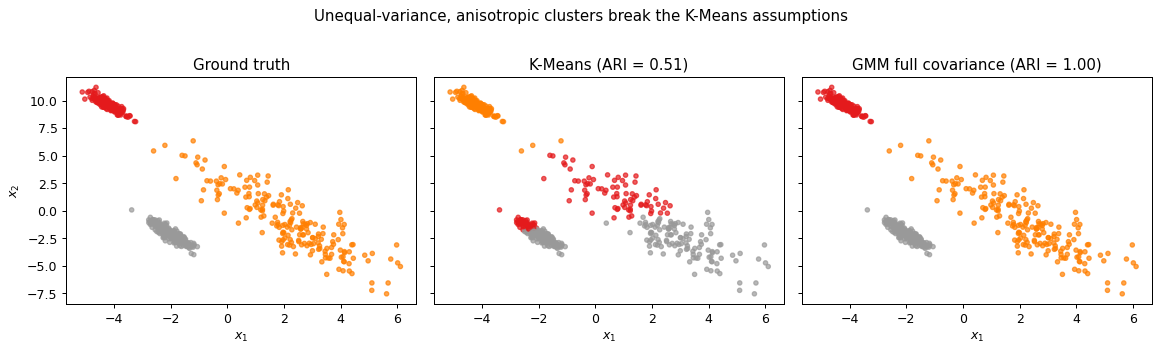

In [8]:
# Experiment: anisotropic, unequal-variance blobs — K-Means vs GMM
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score
from sklearn.mixture import GaussianMixture

X_blob, y_true = make_blobs(
    n_samples=600, centers=3, cluster_std=[0.5, 2.5, 0.6], random_state=SEED
)
X_aniso = X_blob @ np.array([[0.6, -0.6], [-0.3, 0.9]])  # tilt + stretch

km_aniso = KMeans(n_clusters=3, random_state=SEED).fit(X_aniso)
gmm_aniso = GaussianMixture(n_components=3, covariance_type="full", random_state=SEED)
labels_gmm = gmm_aniso.fit(X_aniso).predict(X_aniso)

ari_km = adjusted_rand_score(y_true, km_aniso.labels_)
ari_gmm = adjusted_rand_score(y_true, labels_gmm)
print(f"ARI  K-Means (spherical assumption): {ari_km:.4f}")
print(f"ARI  GMM (full covariance):          {ari_gmm:.4f}")
assert ari_gmm > ari_km, "expected GMM to beat K-Means on anisotropic data"

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True, sharey=True)
for ax, (title, labels) in zip(axes, [
    ("Ground truth", y_true),
    (f"K-Means (ARI = {ari_km:.2f})", km_aniso.labels_),
    (f"GMM full covariance (ARI = {ari_gmm:.2f})", labels_gmm),
]):
    ax.scatter(X_aniso[:, 0], X_aniso[:, 1], c=labels, cmap="Set1", s=12, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
plt.suptitle("Unequal-variance, anisotropic clusters break the K-Means assumptions", y=1.02)
plt.tight_layout()
plt.show()

### Solution 4

**4a.** The K-Means decision boundary between clusters $j$ and $k$ is the perpendicular
bisector of $\mu_j \mu_k$ — a hyperplane. The resulting regions (Voronoi cells) are
intersections of half-spaces, hence convex. A half-moon is non-convex: any placement of
$K = 2$ centroids yields a straight boundary that must cut through one of the moons, so
no initialisation can fix it — the *model class* is wrong, not the optimisation.

**4b.**
1. K-Means minimises unweighted squared Euclidean distance, which implicitly assumes
   identical spherical covariance for every cluster. Points in the tails of the wide
   ($\sigma = 2.5$) cluster lie closer to the *centroids* of the tight clusters than to
   their own, so K-Means slices off those tails (ARI $\approx 0.51$ above).
2. A full-covariance GMM scores points by Mahalanobis distance under each component's own
   $\Sigma_k$ and weighs them by $\pi_k$: an elongated, wide component can "claim" a
   far-away point that a tight component assigns near-zero density. Here it recovers the
   generating partition exactly (ARI $= 1.0$).
3. DBSCAN struggles: the three blobs have very different densities, and a single global
   $\varepsilon$ either fragments the sparse cluster into noise or merges the dense ones
   (theory.md §6.2). Varying density — not shape — is DBSCAN's weak spot.

**4c.** Any pipeline that consumes uncertainty downstream. Example: customer segmentation
for a marketing campaign — a customer with $r = (0.55, 0.45)$ between two segments should
receive either campaign (or a blended one), whereas a hard K-Means label hides that this
customer is borderline. Other examples: soft responsibilities as features for a later
classifier, or outlier flagging via low $\max_k r_{ik}$.